## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors
from rdkit import rdBase
rdBase.DisableLog('rdApp.error')
rdBase.DisableLog('rdApp.warning')
rdBase.DisableLog('rdApp.info')
rdBase.DisableLog('rdApp.debug')

## Importing the dataset

In [2]:
dataset = pd.read_csv('CEPDB_25000.csv')

print("X column names:")
print(dataset.columns[1])
print("\ny column name:")
print(dataset.columns[8])

X column names:
SMILES_str

y column name:
e_gap_alpha


In [3]:
def smiles_to_3d(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    mol = Chem.AddHs(mol)

    try:
        params = AllChem.ETKDG()
        params.randomSeed = 42

        result = AllChem.EmbedMolecule(mol, params)

        if result != 0:
            return None

        return mol

    except Exception as e:
        return None

def extract_3d_features(mol):
    return {
        "RadiusOfGyration": rdMolDescriptors.CalcRadiusOfGyration(mol),
        "Asphericity": rdMolDescriptors.CalcAsphericity(mol),
        "Eccentricity": rdMolDescriptors.CalcEccentricity(mol),
        "InertialShapeFactor": rdMolDescriptors.CalcInertialShapeFactor(mol),
        "SpherocityIndex": rdMolDescriptors.CalcSpherocityIndex(mol),

        # supportive physicochemical descriptors
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
    }

In [ ]:
X_train = []
y_train = []

failed = 0

for _, row in dataset.iterrows():
    mol = smiles_to_3d(row["SMILES_str"])

    if mol is None:
        failed += 1
        continue

    try:
        features = extract_3d_features(mol)
        X_train.append(features)
        y_train.append(row["e_gap_alpha"])
    except Exception:
        failed += 1

# Convert list of dictionaries to numerical DataFrame
X_train = pd.DataFrame(X_train)
y_train = np.array(y_train, dtype=float)

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)
print(X_train.head())
print(X_train.dtypes)

X shape: (24993, 11)
y shape: (24993,)
   RadiusOfGyration  Asphericity  Eccentricity  InertialShapeFactor  \
0          4.437465     0.579681      0.985711             0.000635   
1          4.760304     0.524671      0.980670             0.000417   
2          4.248867     0.658913      0.991408             0.000920   
3          4.180109     0.567643      0.984735             0.000714   
4          3.737606     0.422512      0.965632             0.000627   

   SpherocityIndex    MolWt  MolLogP   TPSA  HBD  HBA  RotBonds  
0     1.583060e-02  395.523   0.6943  67.35    1    5         1  
1     7.455893e-02  467.799   0.3595  15.79    1    2         1  
2     2.049153e-11  400.303   3.9315  67.35    1    4         1  
3     3.211014e-02  389.479   5.9806  26.03    0    3         1  
4     2.210589e-02  326.496   1.8308   0.00    0    1         0  
RadiusOfGyration       float64
Asphericity            float64
Eccentricity           float64
InertialShapeFactor    float64
SpherocityInde

In [4]:
X_train = joblib.load("X_train.pkl")
y_train = joblib.load("y_train.pkl")

## Linear SVR

In [12]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ))
])
svr_rbf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100))])

In [13]:
hopv = pd.read_csv('HOPV_15_revised_2_processed_homo_5fold.csv')

print("X column names:")
print(hopv.columns[0])
print("\ny column name:")
print(hopv.columns[9])

X column names:
smiles

y column name:
electrochemical_gap


In [14]:
X_test = []
y_test = []
test_smiles = []

for _, row in hopv.iterrows():

    # Skip if experimental gap is missing
    if pd.isna(row["electrochemical_gap"]):
        continue

    mol = smiles_to_3d(row["smiles"])

    if mol is None:
        continue

    try:
        features = extract_3d_features(mol)

        X_test.append(features)
        y_test.append(float(row["electrochemical_gap"]))
        test_smiles.append(row["smiles"])

    except Exception:
        continue

X_test = pd.DataFrame(X_test)
y_test = np.array(y_test, dtype=float)

# Make sure feature order is identical to training
X_test = X_test[X_train.columns]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (212, 11)
y_test shape: (212,)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = svr_rbf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("HOPV15 Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

HOPV15 Results
----------------
MAE : 0.463263766160513
RMSE: 0.5974392741732402
R²  : -2.0745196647206137


In [9]:
results = pd.DataFrame({
    "SMILES": test_smiles,
    "Experimental_Gap": y_test,
    "Predicted_Gap": y_pred,
    "Absolute_Error": np.abs(y_test - y_pred)
})

print(results.head(10))
results.to_csv("HOPV15_predictions_linear_svr.csv", index=False)

                                              SMILES  Experimental_Gap  \
0  Cc1nc2c3ccsc3c3sc(-c4ccc(-c5cnc(C6=S=CC=C6)c6n...              2.06   
1  COc1c2ccsc2c(OC)c2cc(-c3scc4sc(C(C)=O)c(F)c43)...              1.77   
2  COc1c2ccsc2c(OC)c2cc(-c3sc(-c4sc(-c5cc(C)cs5)c...              1.89   
3  CC1(C)c2ccccc2-c2ccc(-c3ccc(C4=C(c5ccccc5)C(c5...              2.11   
4  COC(=O)C(C#N)=Cc1cc(C)c(-c2cc(C)c(-c3cc(C)c(-c...              1.84   
5  COc1c2ccsc2c(OC)c2cc(-c3ccc(-c4c5nonc5c(-c5ccc...              2.11   
6  Cc1ccc(-c2ccc(-c3ncc(-c4cc5c(s4)-c4sc(-c6cnc(-...              1.56   
7  Cc1ccc(-n2c(-c3ccsc3)nc3c2c2ccc(C)cc2c2cc(C)cc...              1.80   
8  CN1C(=O)C2=C(c3ccc(-c4cccs4)o3)N(C)C(=O)C2=C1c...              1.60   
9  C=Cc1ccc2c3ccc(C=Cc4ccc(-c5ccc(C6=C(C)C(C)=C(c...              2.00   

   Predicted_Gap  Absolute_Error  
0       1.218856        0.841144  
1       1.531801        0.238199  
2       1.035280        0.854720  
3       1.625823        0.484177  
4      -0.

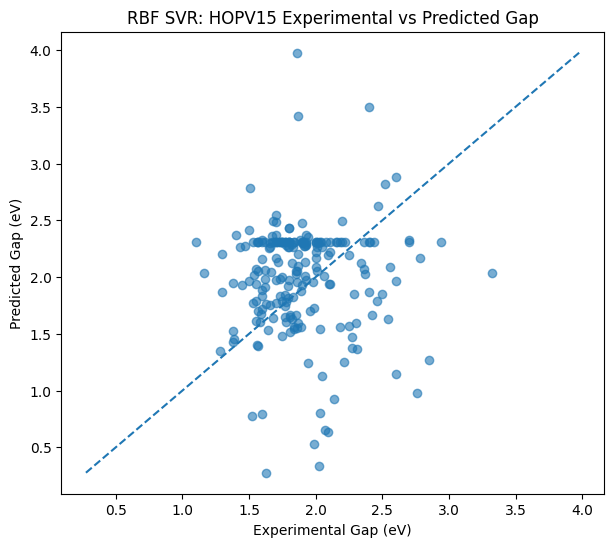

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Experimental Gap (eV)")
plt.ylabel("Predicted Gap (eV)")
plt.title("RBF SVR: HOPV15 Experimental vs Predicted Gap")

plt.show()

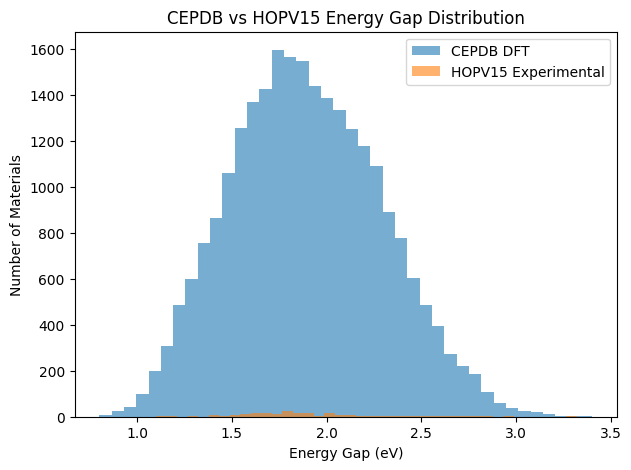

In [17]:
plt.figure(figsize=(7,5))

plt.hist(y_train, bins=40, alpha=0.6, label="CEPDB DFT")
plt.hist(y_test, bins=40, alpha=0.6, label="HOPV15 Experimental")

plt.xlabel("Energy Gap (eV)")
plt.ylabel("Number of Materials")
plt.title("CEPDB vs HOPV15 Energy Gap Distribution")
plt.legend()
plt.show()